Saving data.csv to data (4).csv
Explained Variance: 0.9510575059327271

===== ACCURACY =====
Train Accuracy: 0.9846
Test Accuracy : 0.9825

===== METRICS =====
Precision: 0.9859154929577465
Recall   : 0.9859154929577465
F1 Score : 0.9859154929577465
ROC-AUC  : 0.9977071732721913


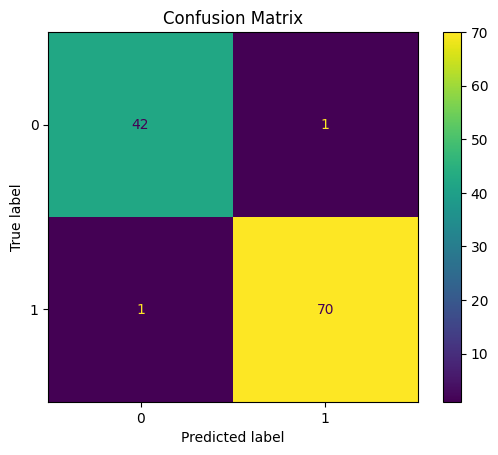

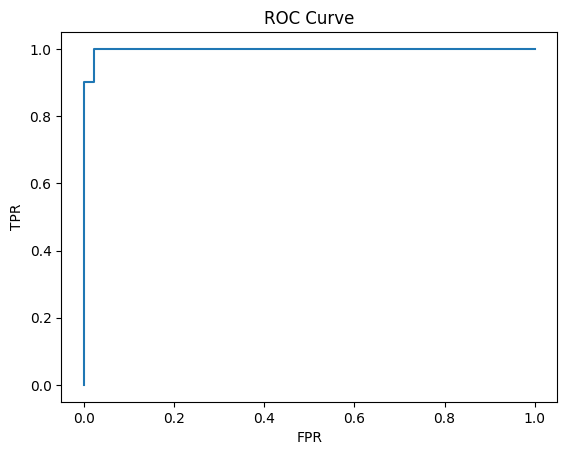

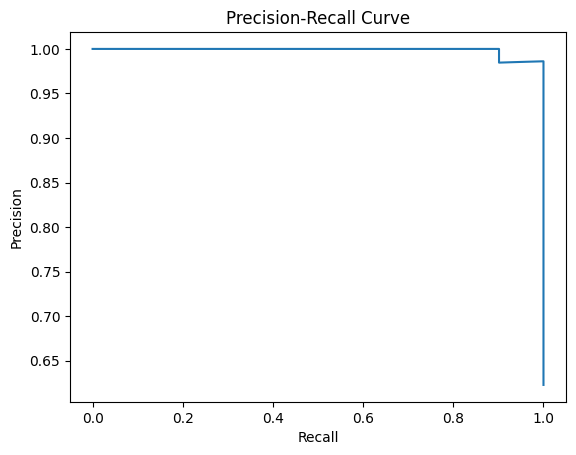

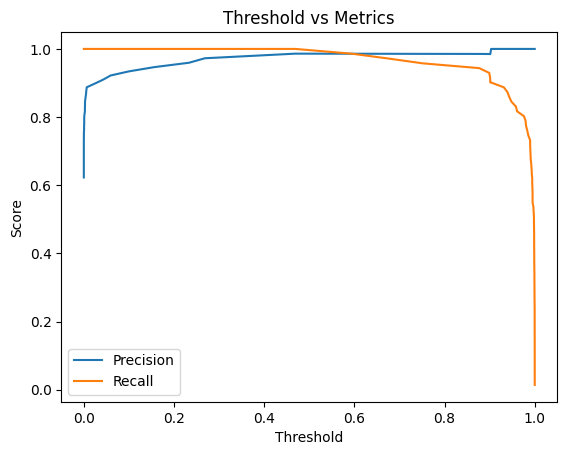

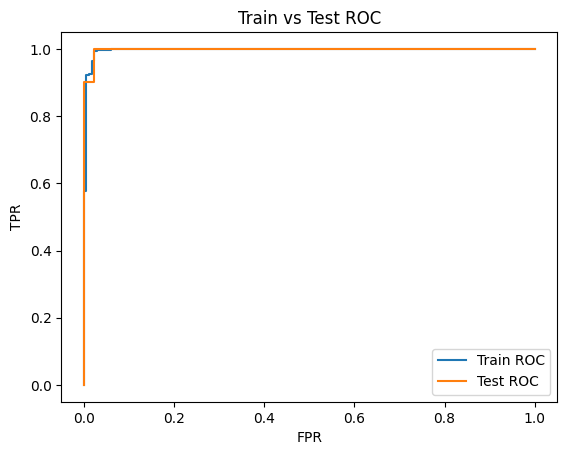

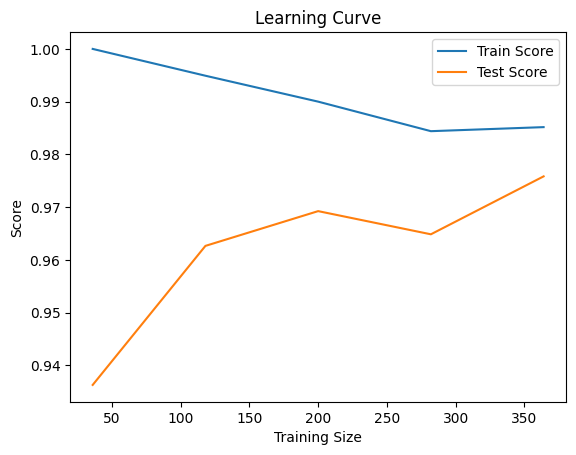

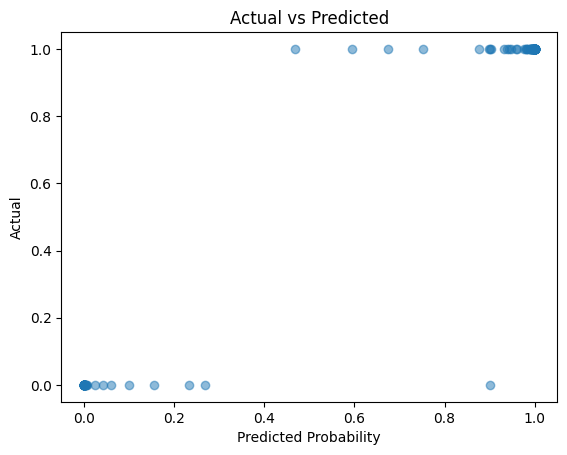


===== AFTER THRESHOLD TUNING =====
Precision: 0.9861111111111112
Recall   : 1.0


In [9]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, accuracy_score
)

# =========================================
# 2. LOAD DATA
# =========================================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# =========================================
# 3. PREPROCESSING
# =========================================
def preprocess(X_train, X_test, n_components=10):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    pca = PCA(n_components=n_components)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    print("Explained Variance:", sum(pca.explained_variance_ratio_))
    return X_train, X_test

# =========================================
# 4. TRAIN MODEL
# =========================================
def train_model(X_train, y_train):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return model

# =========================================
# 5. CHECK ACCURACY
# =========================================
def check_accuracy(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("\n===== ACCURACY =====")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")

# =========================================
# 6. EVALUATION METRICS
# =========================================
def evaluate(y_test, y_pred, y_prob):
    print("\n===== METRICS =====")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# =========================================
# 7. PLOTS
# =========================================

# Confusion Matrix
def plot_confusion(y_test, y_pred):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Confusion Matrix")
    plt.show()

# ROC Curve (Test)
def plot_roc(y_test, y_prob):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.show()

# Precision-Recall Curve
def plot_pr(y_test, y_prob):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

# Threshold Curve
def plot_threshold(y_test, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    plt.plot(thresholds, precision[:-1], label="Precision")
    plt.plot(thresholds, recall[:-1], label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold vs Metrics")
    plt.legend()
    plt.show()

# Train vs Test ROC Curve
def plot_train_test_roc(model, X_train, y_train, X_test, y_test):
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_prob)

    plt.plot(fpr_train, tpr_train, label="Train ROC")
    plt.plot(fpr_test, tpr_test, label="Test ROC")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Train vs Test ROC")
    plt.legend()
    plt.show()

# Learning Curve
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5
    )

    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
    plt.plot(train_sizes, test_scores.mean(axis=1), label="Test Score")
    plt.xlabel("Training Size")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

# Actual vs Predicted
def plot_actual_vs_pred(y_test, y_prob):
    plt.scatter(y_prob, y_test, alpha=0.5)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Actual")
    plt.title("Actual vs Predicted")
    plt.show()

# =========================================
# 8. MAIN
# =========================================
def main():
    X, y = load_data()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    X_train, X_test = preprocess(X_train, X_test)

    model = train_model(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Accuracy
    check_accuracy(model, X_train, y_train, X_test, y_test)

    # Metrics
    evaluate(y_test, y_pred, y_prob)

    # Plots
    plot_confusion(y_test, y_pred)
    plot_roc(y_test, y_prob)
    plot_pr(y_test, y_prob)
    plot_threshold(y_test, y_prob)
    plot_train_test_roc(model, X_train, y_train, X_test, y_test)
    plot_learning_curve(model, X_train, y_train)
    plot_actual_vs_pred(y_test, y_prob)

    # Threshold tuning
    threshold = 0.3
    y_pred_custom = (y_prob >= threshold).astype(int)

    print("\n===== AFTER THRESHOLD TUNING =====")
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall   :", recall_score(y_test, y_pred_custom))


# =========================================
# RUN
# =========================================
if __name__ == "__main__":
    main()